# Chunk-Level XGBoost — OF (Deployment-Safe Features)

Trains XGBoost on deployment-safe features only and evaluates at chunk level.

**Features excluded (not available at prediction time):**  
`Travel_Distance`, `same_aisle`, `same_lockey`, `same_location`, `same_level`, `diff_level`, `time_of_day`, `day_of_week`, `hour`

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("../data/processed")
WAREHOUSE    = "OF"
WORKCODES    = ["10", "20", "30"]
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026

# Features not available at prediction time — excluded from XGBoost
NOT_AVAILABLE = [
    "Travel_Distance",
    "same_aisle", "same_lockey", "same_location", "same_level", "diff_level",
    "time_of_day", "day_of_week", "hour",
]


In [ ]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


_df_raw = pd.read_parquet(resolve_data_path(WAREHOUSE))
_df_raw["WorkCode"] = _df_raw["WorkCode"].astype(str).apply(
    lambda x: x.split(".")[0] if isinstance(x, str) else x
)
WORKCODES = sorted(_df_raw["WorkCode"].dropna().unique().tolist())
print(f"WorkCodes found: {WORKCODES}")
del _df_raw



def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days    = sorted(df["date"].dropna().unique())
    n_test_days = max(1, int(round(len(all_days) * test_ratio)))
    test_days   = all_days[-n_test_days:]
    train_df    = df[df["date"] < test_days[0]].copy()
    test_df     = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def eval_predictions(y_true, pred):
    return {
        "r2":   r2_score(y_true, pred),
        "mae":  mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }


def make_test_blocks(test_df, block_size=BLOCK_SIZE):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.sort_values("Timestamp").reset_index().rename(columns={"index": "orig_index"}).copy()
        for start in range(0, len(g), block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size:
                continue
            if chunk["WorkCode"].nunique() != 1:
                continue
            if (chunk["Time_Delta_sec"] > MAX_TIME).any():
                continue
            block_id = f"{uid}_{day}_{start // block_size}"
            chunk["BlockID"] = block_id
            block_rows.append(chunk)
            blocks.append({
                "BlockID":     block_id,
                "UserID":      uid,
                "date":        day,
                "WorkCode":    chunk["WorkCode"].iloc[0],
                "n_tasks":     len(chunk),
                "actual_time": chunk["Time_Delta_sec"].sum(),
                "start_ts":    chunk["Timestamp"].min(),
                "end_ts":      chunk["Timestamp"].max(),
            })
    block_df     = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


In [3]:
all_task_results  = []
all_block_results = []
all_block_detail  = []

xgb_params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:tweedie",
    tweedie_variance_power=1.3,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc}")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)
    print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
    print(f"Features: {features}")

    y_train = train_df["Time_Delta_sec"].astype(float)
    y_test  = test_df["Time_Delta_sec"].astype(float)

    X_train, X_test = make_X(train_df, test_df, features, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    all_task_results.append({
        "Warehouse":    WAREHOUSE,
        "WorkCode":     wc,
        "n_train_rows": len(train_df),
        "n_test_rows":  len(test_df),
        "runtime_sec":  runtime,
        **eval_predictions(y_test, preds)
    })

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail.append(block_pred)

task_results_df  = pd.DataFrame(all_task_results)
block_results_df = pd.DataFrame(all_block_results)
block_detail_df  = pd.concat(all_block_detail, ignore_index=True) if all_block_detail else pd.DataFrame()
print("\nDone.")



WorkCode 10
Train: 3753 rows | Test: 923 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
  Blocks: 13 | MAE: 734.8s | MAE/task: 14.696s | R²: 0.4203

WorkCode 20
Train: 35198 rows | Test: 4940 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
  Blocks: 85 | MAE: 601.0s | MAE/task: 12.019s | R²: 0.4011

WorkCode 30
Train: 67061 rows | Test: 8397 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
  Blocks: 149 | MAE: 588.9s | MAE/task: 11.779s | R²: 0.1861

Done.


In [4]:
block_results_clean = block_results_df.copy()
for c in ["r2", "mae", "rmse"]:
    if c in block_results_clean.columns:
        block_results_clean[c] = block_results_clean[c].round(3)
block_results_clean["mae_per_task"] = (block_results_clean["mae"] / BLOCK_SIZE).round(3)
block_results_clean = block_results_clean.drop(columns=["rmse", "Warehouse"], errors="ignore")

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(block_results_clean.sort_values(["WorkCode", "mae_per_task"]).reset_index(drop=True))


Warehouse: OF | Block size: 50 tasks


,WorkCode,n_blocks,r2,mae,mae_per_task
0,10,13,0.420,734.805,14.696
1,20,85,0.401,600.974,12.019
2,30,149,0.186,588.943,11.779


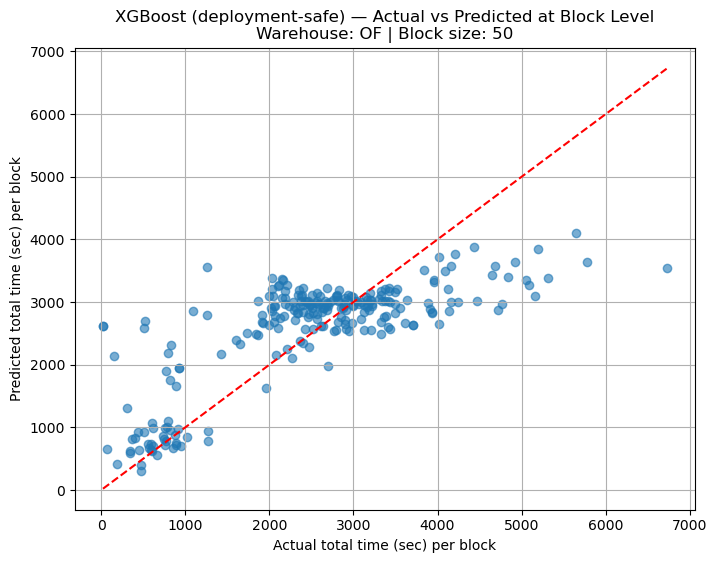

In [5]:
plot_df = block_detail_df[block_detail_df["Warehouse"] == WAREHOUSE].copy()
plot_df = plot_df[plot_df["pred"].notna()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual_time"], plot_df["pred"], alpha=0.6)
plt.plot(
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual total time (sec) per block")
plt.ylabel("Predicted total time (sec) per block")
plt.title(f"XGBoost (deployment-safe) — Actual vs Predicted at Block Level\n"
          f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE}")
plt.grid(True)
plt.show()


In [6]:
df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, "10", MAX_TIME)
print(features)


['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']


In [7]:
# ── Worker Random Intercept (Mixed Effects) ────────────────────────────────
# Fits Time_Delta_sec ~ 1 + (1|UserID) on training data only.
# Extracts per-worker effect b_j and adds it as a feature to XGBoost.
# Unseen workers at test time get effect = 0 (grand mean fallback).

def estimate_worker_effects(train_df):
    """
    Fits a random intercept model on training data.
    Returns a DataFrame with columns [UserID, worker_effect].
    worker_effect is the b_j estimate: positive = slower than average.
    """
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        print("  [Warning] Not enough workers — skipping worker effects")
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})

    result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    icc = result.cov_re.values[0][0] / (result.cov_re.values[0][0] + result.scale)
    print(f"  Grand mean: {result.fe_params['Intercept']:.1f}s | "
          f"Worker SD: {np.sqrt(result.cov_re.values[0][0]):.1f}s | ICC: {icc:.3f}")

    return pd.DataFrame({
        "UserID":        list(result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in result.random_effects.values()]
    })


all_block_results_w = []
all_block_detail_w  = []

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc} — + Worker Effect")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)

    # Estimate worker effects on training data only — no leakage
    print("  Fitting mixed model...")
    worker_effects = estimate_worker_effects(train_df)

    # Join worker_effect — unseen workers get 0 (grand mean fallback)
    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # Add worker_effect to feature set
    feats_w = features + ["worker_effect"]
    X_train, X_test = make_X(train_df, test_df, feats_w, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"  No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results_w.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail_w.append(block_pred)

block_results_w_df = pd.DataFrame(all_block_results_w)
block_detail_w_df  = pd.concat(all_block_detail_w, ignore_index=True) if all_block_detail_w else pd.DataFrame()
print("\nDone.")



WorkCode 10 — + Worker Effect
  Fitting mixed model...
  Grand mean: 81.3s | Worker SD: 21.9s | ICC: 0.124
  Blocks: 13 | MAE: 430.2s | MAE/task: 8.603s | R²: 0.6952

WorkCode 20 — + Worker Effect
  Fitting mixed model...
  Grand mean: 45.7s | Worker SD: 14.8s | ICC: 0.069
  Blocks: 85 | MAE: 615.6s | MAE/task: 12.312s | R²: 0.2622

WorkCode 30 — + Worker Effect
  Fitting mixed model...
  Grand mean: 72.5s | Worker SD: 22.7s | ICC: 0.176
  Blocks: 149 | MAE: 393.1s | MAE/task: 7.862s | R²: 0.6511

Done.


In [8]:
# Compare baseline vs + worker at chunk level
rows = []
for wc in WORKCODES:
    base = block_results_df[block_results_df["WorkCode"] == wc]
    enh  = block_results_w_df[block_results_w_df["WorkCode"] == wc]
    if base.empty or enh.empty:
        continue
    mae_base = base["mae"].values[0]
    mae_enh  = enh["mae"].values[0]
    rows.append({
        "WorkCode":              wc,
        "MAE/task baseline (s)": round(mae_base / BLOCK_SIZE, 3),
        "MAE/task + worker (s)": round(mae_enh  / BLOCK_SIZE, 3),
        "Improvement (s)":       round((mae_base - mae_enh) / BLOCK_SIZE, 3),
        "Improvement (%)": round((mae_base - mae_enh) / mae_base * 100, 2),
        "R² baseline":           round(base["r2"].values[0], 4),
        "R² + worker":           round(enh["r2"].values[0],  4),
    })

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(pd.DataFrame(rows))


Warehouse: OF | Block size: 50 tasks


,WorkCode,MAE/task baseline (s),MAE/task + worker (s),Improvement (s),Improvement (%),R² baseline,R² + worker
0,10,14.696,8.603,6.093,41.46,0.4203,0.6952
1,20,12.019,12.312,-0.293,-2.44,0.4011,0.2622
2,30,11.779,7.862,3.917,33.25,0.1861,0.6511


# WC10 — strong positive result
Worker effects help substantially. MAE/task drops from 14.696s to 8.603s, a 41% improvement, and R² jumps from 0.42 to 0.70. With 13 test blocks this is more reliable than OE WC10. The ICC of 0.124 confirms meaningful worker signal — worker identity explains 12% of pick time variance — and the model is successfully capturing it.

# WC30 — strong positive result
MAE/task drops from 11.779s to 7.862s, a 33% improvement, and R² jumps from 0.19 to 0.65. ICC of 0.176 confirms strong worker signal. This is consistent with OE WC30 and validates that the worker effect generalizes across warehouses.

# WC20 — worker effects hurt
Same pattern as OE. MAE/task goes from 12.019s to 12.312s, getting 2% worse. ICC is 0.069 — weak worker signal. The effect is small but the direction is wrong. Same explanation as OE: weak worker signal means the estimates are noisy and add more error than they remove.

# Overall conclusion
OF shows the clearest results of all three warehouses. Worker effects produce large improvements on WC10 and WC30 where ICC is meaningful, and fail on WC20 where ICC is low. The pattern is identical to OE, which is strong evidence that the finding generalizes across warehouse environments.
